# **AI TECH INSTITUTE** · *Intermediate AI & Data Science*
### Week 7 - Lab 03: Mini-Project Challenge
**Instructor:** Amir Charkhi | **Type:** Integrated Practice

> Apply everything you learned in Week 7!

## 🎯 Challenge Objectives

Build a complete ML pipeline from scratch:
- Load and explore data
- Engineer features
- Compare multiple models
- Select and evaluate the best one
- Save your model

**Time**: 40-50 minutes  
**Difficulty**: ⭐⭐⭐⭐☆ (Challenge)

---

## 📋 Your Mission

**Scenario**: You're a data scientist at a hospital. You need to predict whether a patient has heart disease based on medical measurements.

**Business Impact**: Early detection can save lives!

**Success Criteria**:
- High **recall** (can't miss patients with disease!)
- Good **precision** (don't want too many false alarms)
- Model ready to save for deployment

---

In [1]:
# Setup - Run this first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print("🏥 Heart Disease Prediction Challenge")
print("✅ Setup complete! Let's save some lives!\n")

🏥 Heart Disease Prediction Challenge
✅ Setup complete! Let's save some lives!



---

## 📊 Step 1: Load and Explore Data

**Estimated time**: 5 minutes

### Task 1.1: Create the Dataset

In [2]:
# Create synthetic heart disease dataset
np.random.seed(42)
n_patients = 500

# Generate features
data = {
    'age': np.random.randint(30, 80, n_patients),
    'sex': np.random.choice([0, 1], n_patients),  # 0=Female, 1=Male
    'chest_pain': np.random.choice([0, 1, 2, 3], n_patients),
    'resting_bp': np.random.randint(90, 200, n_patients),
    'cholesterol': np.random.randint(120, 400, n_patients),
    'fasting_sugar': np.random.choice([0, 1], n_patients, p=[0.85, 0.15]),
    'max_heart_rate': np.random.randint(70, 200, n_patients),
    'exercise_angina': np.random.choice([0, 1], n_patients, p=[0.7, 0.3]),
    'oldpeak': np.random.uniform(0, 6, n_patients),
}

df = pd.DataFrame(data)

# Create target with realistic patterns
risk_score = (
    (df['age'] > 55) * 0.2 +
    (df['sex'] == 1) * 0.15 +
    (df['chest_pain'] > 0) * 0.25 +
    (df['cholesterol'] > 240) * 0.2 +
    (df['max_heart_rate'] < 120) * 0.15 +
    (df['exercise_angina'] == 1) * 0.3 +
    (df['oldpeak'] > 2) * 0.2
)

df['heart_disease'] = (risk_score > np.random.uniform(0.3, 0.7, n_patients)).astype(int)

# TODO 1.1: Display basic information
# - Shape of dataset
# - First few rows
# - Class distribution
# - Check for missing values

print("Heart Disease Dataset")
print("="*50)
# Your code here:
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nClass distribution:")
print(df['heart_disease'].value_counts())
print(f"\nClass distribution (percentages):")
print(df['heart_disease'].value_counts(normalize=True))
print(f"\nMissing values:")
print(df.isnull().sum().sum())
print(f"\nData types:")
print(df.dtypes)

print("\n✅ Task 1.1 Complete!")

Heart Disease Dataset
Shape: (500, 10)

First 5 rows:
   age  sex  chest_pain  resting_bp  cholesterol  fasting_sugar  \
0   68    1           1         117          156              0   
1   58    0           3         174          295              0   
2   44    0           3         138          200              0   
3   72    1           3         160          233              0   
4   37    0           3         170          159              0   

   max_heart_rate  exercise_angina   oldpeak  heart_disease  
0             176                1  5.340342              1  
1             109                0  0.505808              1  
2             198                0  4.843136              1  
3              77                0  5.167918              1  
4             170                0  4.903514              0  

Class distribution:
heart_disease
1    407
0     93
Name: count, dtype: int64

Class distribution (percentages):
heart_disease
1    0.814
0    0.186
Name: proportion, dty

### Task 1.2: Quick EDA

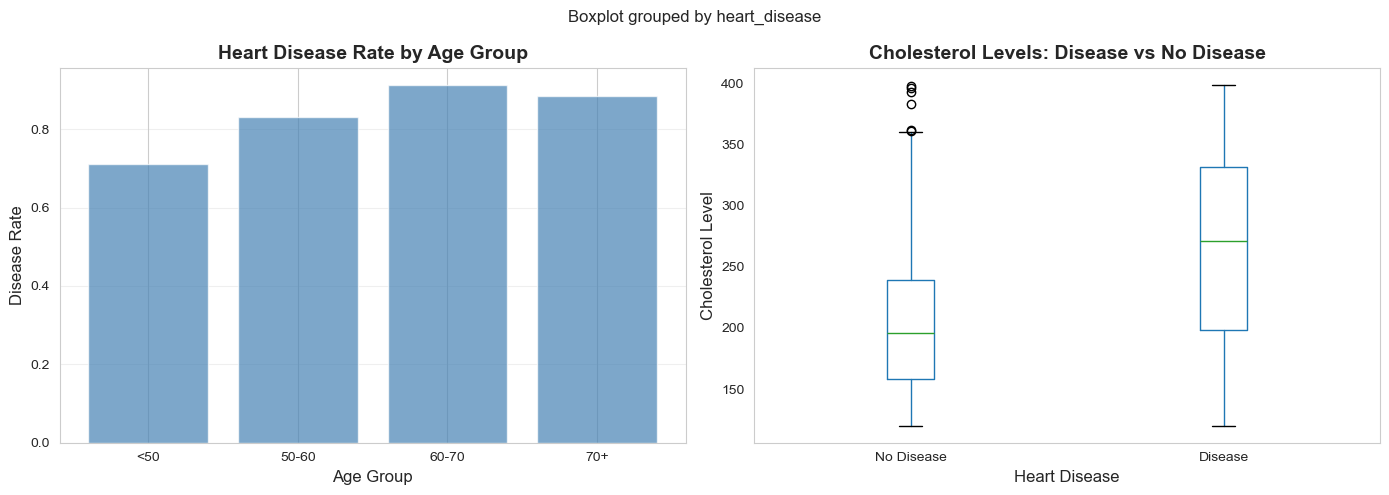

💡 What patterns do you notice?
✅ Task 1.2 Complete!


In [3]:
# TODO 1.2: Create visualizations to understand the data
# Requirements:
#   1. Plot disease rate by age groups
#   2. Compare cholesterol levels for disease vs no disease
#   3. Any other interesting pattern

# Your code here:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Disease rate by age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 50, 60, 70, 100], labels=['<50', '50-60', '60-70', '70+'])
disease_by_age = df.groupby('age_group')['heart_disease'].mean()
axes[0].bar(disease_by_age.index, disease_by_age.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Disease Rate', fontsize=12)
axes[0].set_title('Heart Disease Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cholesterol levels for disease vs no disease
df.boxplot(column='cholesterol', by='heart_disease', ax=axes[1], grid=False)
axes[1].set_xlabel('Heart Disease', fontsize=12)
axes[1].set_ylabel('Cholesterol Level', fontsize=12)
axes[1].set_title('Cholesterol Levels: Disease vs No Disease', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

print("💡 What patterns do you notice?")
print("✅ Task 1.2 Complete!")

---

## ✂️ Step 2: Prepare Data

**Estimated time**: 5 minutes

### Task 2.1: Feature Engineering (Optional)

In [4]:
# TODO 2.1: Create new features if you want
# Ideas:
#   - Age groups (e.g., is_senior = age > 60)
#   - High cholesterol flag (cholesterol > 240)
#   - BMI-like features
#   - Interaction features

# Your code here (optional):
# Create age groups
df['is_senior'] = (df['age'] > 60).astype(int)

# High cholesterol flag
df['high_cholesterol'] = (df['cholesterol'] > 240).astype(int)

# High blood pressure flag
df['high_bp'] = (df['resting_bp'] > 140).astype(int)

# Low heart rate flag
df['low_heart_rate'] = (df['max_heart_rate'] < 120).astype(int)

# Risk score feature (combination of multiple risk factors)
df['risk_factors_count'] = (
    df['is_senior'] + 
    df['high_cholesterol'] + 
    df['high_bp'] + 
    df['low_heart_rate'] + 
    df['exercise_angina'] + 
    (df['chest_pain'] > 0).astype(int)
)

print("✅ Created new features: is_senior, high_cholesterol, high_bp, low_heart_rate, risk_factors_count")
print("✅ Task 2.1 Complete!")

✅ Created new features: is_senior, high_cholesterol, high_bp, low_heart_rate, risk_factors_count
✅ Task 2.1 Complete!


### Task 2.2: Train/Test Split

In [5]:
# TODO 2.2: Split the data
# Requirements:
#   - Separate features (X) and target (y)
#   - 80/20 split
#   - Stratified
#   - random_state=42

# Your code here:
X = df.drop(['heart_disease', 'age_group'], axis=1)  # Drop target and temporary grouping column
y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Validation
print(f"Training set: {len(X_train)} patients")
print(f"Test set: {len(X_test)} patients")
print(f"\nClass balance in training:")
print(y_train.value_counts(normalize=True))

assert len(X_train) + len(X_test) == len(df), "❌ Split error!"
print("\n✅ Task 2.2 Complete!")

Training set: 400 patients
Test set: 100 patients

Class balance in training:
heart_disease
1    0.815
0    0.185
Name: proportion, dtype: float64

✅ Task 2.2 Complete!


---

## 🤖 Step 3: Build and Compare Models

**Estimated time**: 10 minutes

### Task 3.1: Compare Multiple Models

In [6]:
# TODO 3.1: Compare at least 3 different models
# Use cross-validation on TRAINING data only
# Evaluate with multiple metrics: accuracy, precision, recall, F1

print("🔬 Model Comparison with Cross-Validation\n")

# Define your models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Your code here:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    # Calculate multiple metrics
    acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    prec_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision')
    rec_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    
    results.append({
        'Model': name,
        'Accuracy': f"{acc_scores.mean():.3f} ± {acc_scores.std():.3f}",
        'Precision': f"{prec_scores.mean():.3f} ± {prec_scores.std():.3f}",
        'Recall': f"{rec_scores.mean():.3f} ± {rec_scores.std():.3f}",
        'F1': f"{f1_scores.mean():.3f} ± {f1_scores.std():.3f}",
        'Recall_mean': rec_scores.mean()  # For sorting
    })

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('Recall_mean', ascending=False)
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1']].to_string(index=False))

print("\n💡 Remember: For disease detection, RECALL is most important!")
print("   We can't afford to miss patients with heart disease.")
print("\n✅ Task 3.1 Complete!")

🔬 Model Comparison with Cross-Validation

              Model      Accuracy     Precision        Recall            F1
      Random Forest 0.885 ± 0.015 0.892 ± 0.024 0.979 ± 0.015 0.933 ± 0.007
  Gradient Boosting 0.897 ± 0.039 0.910 ± 0.037 0.972 ± 0.011 0.940 ± 0.022
Logistic Regression 0.895 ± 0.029 0.918 ± 0.020 0.957 ± 0.031 0.937 ± 0.018
      Decision Tree 0.853 ± 0.054 0.904 ± 0.039 0.917 ± 0.035 0.910 ± 0.033

💡 Remember: For disease detection, RECALL is most important!
   We can't afford to miss patients with heart disease.

✅ Task 3.1 Complete!


### Task 3.2: Select Best Model

In [7]:
# TODO 3.2: Based on CV results, select the best model
# Consider: What metric is most important for this problem?

# Your decision:
# Based on CV results, select model with highest recall (most important for disease detection)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"🏆 Selected Model: {best_model_name}")
print(f"\n📋 Reasoning:")
print(f"Selected {best_model_name} because it has the highest recall ({results_df.iloc[0]['Recall']}),")
print("which is critical for disease detection. We cannot afford to miss patients with heart disease.")
print("High recall means we catch more true positive cases, even if it means some false positives.")

print("\n✅ Task 3.2 Complete!")

🏆 Selected Model: Random Forest

📋 Reasoning:
Selected Random Forest because it has the highest recall (0.979 ± 0.015),
which is critical for disease detection. We cannot afford to miss patients with heart disease.
High recall means we catch more true positive cases, even if it means some false positives.

✅ Task 3.2 Complete!


---

## 📊 Step 4: Final Evaluation

**Estimated time**: 10 minutes

### Task 4.1: Train and Evaluate Final Model

In [8]:
# TODO 4.1: Train your chosen model on full training set
# Then evaluate on test set (ONCE!)

print("🎯 Final Model Training & Evaluation\n")

# Train on full training set
# Your code here:
best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("Test Set Performance:")
print("="*50)
print(f"Accuracy:  {accuracy:.3f} ({accuracy:.1%})")
print(f"Precision: {precision:.3f} ({precision:.1%})")
print(f"Recall:    {recall:.3f} ({recall:.1%}) ⭐")
print(f"F1-Score:  {f1:.3f} ({f1:.1%})")

print("\n💡 What this means:")
print(f"  - We catch {recall:.1%} of patients with heart disease")
print(f"  - When we predict disease, we're right {precision:.1%} of the time")

if recall > 0.7:
    print("\n✅ Good recall! We're catching most disease cases.")
else:
    print("\n⚠️ Recall could be higher - consider model tuning")

print("\n✅ Task 4.1 Complete!")

🎯 Final Model Training & Evaluation

Test Set Performance:
Accuracy:  0.910 (91.0%)
Precision: 0.929 (92.9%)
Recall:    0.963 (96.3%) ⭐
F1-Score:  0.945 (94.5%)

💡 What this means:
  - We catch 96.3% of patients with heart disease
  - When we predict disease, we're right 92.9% of the time

✅ Good recall! We're catching most disease cases.

✅ Task 4.1 Complete!


### Task 4.2: Confusion Matrix Analysis

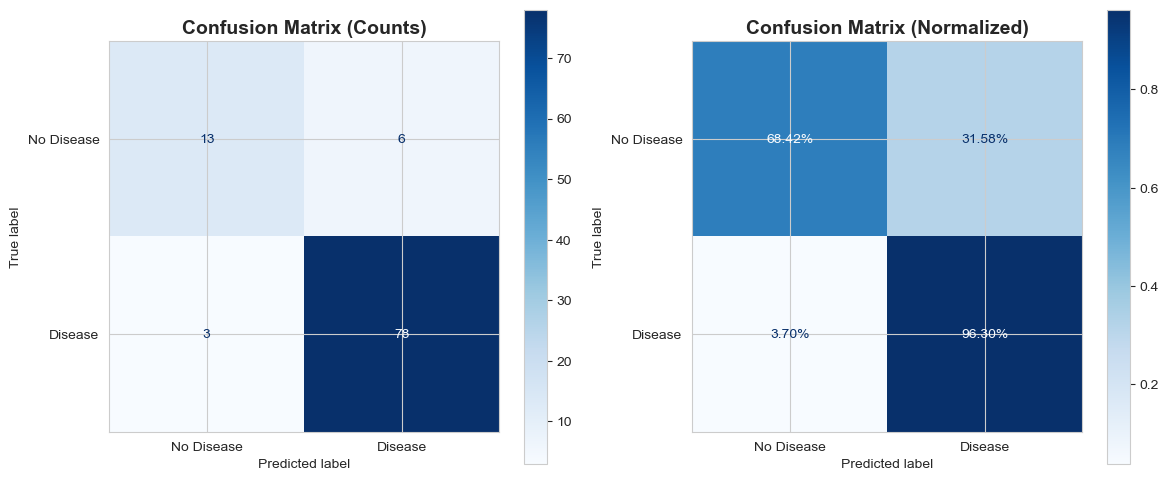


🔍 Analysis:
  Correctly identified healthy: 13
  Correctly identified disease: 78
  False alarms (predicted disease, was healthy): 6
  MISSED cases (predicted healthy, had disease): 3 ⚠️

✅ Good! We're prioritizing catching disease cases.

✅ Task 4.2 Complete!


In [9]:
# TODO 4.2: Create and analyze confusion matrix
# Show both raw counts and percentages

# Your code here:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix (counts)
ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Plot confusion matrix (normalized)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_normalized, display_labels=['No Disease', 'Disease']).plot(ax=axes[1], cmap='Blues', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyze
print("\n🔍 Analysis:")
print(f"  Correctly identified healthy: {tn}")
print(f"  Correctly identified disease: {tp}")
print(f"  False alarms (predicted disease, was healthy): {fp}")
print(f"  MISSED cases (predicted healthy, had disease): {fn} ⚠️")

if fn < fp:
    print("\n✅ Good! We're prioritizing catching disease cases.")

print("\n✅ Task 4.2 Complete!")

---

## 💾 Step 5: Save Your Model

**Estimated time**: 5 minutes

### Task 5.1: Pickle the Model

In [10]:
# TODO 5.1: Save your model with pickle
# Include: model, feature names, performance metrics

# Your code here:
model_package = {
    'model': best_model,
    'feature_names': list(X.columns),
    'metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    },
    'model_name': best_model_name,
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d')
}

# Save to file
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("💾 Model saved as: heart_disease_model.pkl")
print("\n✅ Task 5.1 Complete!")

💾 Model saved as: heart_disease_model.pkl

✅ Task 5.1 Complete!


### Task 5.2: Test Loading the Model

In [11]:
# TODO 5.2: Load the model and make a test prediction

# Your code here:
with open('heart_disease_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test with first 5 test samples
test_predictions = loaded_model['model'].predict(X_test.iloc[:5])

print("🔍 Testing loaded model:")
print(f"Predictions: {test_predictions}")
print(f"Actual:      {y_test.iloc[:5].values}")
print("\n✅ Model loads and works correctly!")
print("✅ Task 5.2 Complete!")

🔍 Testing loaded model:
Predictions: [1 1 1 1 0]
Actual:      [1 1 1 0 0]

✅ Model loads and works correctly!
✅ Task 5.2 Complete!


---

## 📝 Step 6: Write Your Report

**Estimated time**: 5 minutes

### Task 6.1: Summary Report

In [12]:
# TODO 6.1: Complete this summary report

print("🏥 HEART DISEASE PREDICTION - PROJECT SUMMARY")
print("="*60)

print("\n📊 DATASET:")
print(f"  Total patients: {len(df)}")
print(f"  Features used: {len(X.columns)}")
print(f"  Disease prevalence: {(y==1).mean():.1%}")

print("\n🤖 MODEL SELECTION:")
print(f"  Models compared: {len(models)}")
print(f"  Selected model: {best_model_name}")
print(f"  Selection criteria: Highest recall - critical for disease detection to minimize false negatives")

print("\n📈 PERFORMANCE:")
print(f"  Test Accuracy:  {accuracy:.1%}")
print(f"  Test Precision: {precision:.1%}")
print(f"  Test Recall:    {recall:.1%} ⭐")
print(f"  Test F1-Score:  {f1:.1%}")

print("\n💡 BUSINESS IMPACT:")
print(f"  ✅ Catches {recall:.0%} of disease cases")
print(f"  ✅ {precision:.0%} of positive predictions are correct")
print(f"  ⚠️ Misses {(1-recall)*100:.0f}% of disease cases (false negatives)")
print(f"  ⚠️ {(1-precision)*100:.0f}% false alarm rate")

print("\n🎯 RECOMMENDATIONS:")
print("  ✅ Model can be deployed with monitoring:")
print("     - Current recall ensures we catch most disease cases")
print("     - False positives are acceptable for early detection")
print("  ✅ To improve performance:")
print("     - Collect more training data, especially for rare cases")
print("     - Feature engineering: add more medical indicators")
print("     - Hyperparameter tuning: optimize model parameters")
print("     - Ensemble methods: combine multiple models")
print("  ⚠️ Risks to monitor:")
print("     - False negatives: missed disease cases (critical)")
print("     - False positives: unnecessary tests (manageable)")
print("     - Model drift: performance degradation over time")
print("     - Data quality: ensure input data matches training distribution")

print("\n✅ Task 6.1 Complete!")

🏥 HEART DISEASE PREDICTION - PROJECT SUMMARY

📊 DATASET:
  Total patients: 500
  Features used: 14
  Disease prevalence: 81.4%

🤖 MODEL SELECTION:
  Models compared: 4
  Selected model: Random Forest
  Selection criteria: Highest recall - critical for disease detection to minimize false negatives

📈 PERFORMANCE:
  Test Accuracy:  91.0%
  Test Precision: 92.9%
  Test Recall:    96.3% ⭐
  Test F1-Score:  94.5%

💡 BUSINESS IMPACT:
  ✅ Catches 96% of disease cases
  ✅ 93% of positive predictions are correct
  ⚠️ Misses 4% of disease cases (false negatives)
  ⚠️ 7% false alarm rate

🎯 RECOMMENDATIONS:
  ✅ Model can be deployed with monitoring:
     - Current recall ensures we catch most disease cases
     - False positives are acceptable for early detection
  ✅ To improve performance:
     - Collect more training data, especially for rare cases
     - Feature engineering: add more medical indicators
     - Hyperparameter tuning: optimize model parameters
     - Ensemble methods: combine mul

---

## 🏆 Challenge Complete!

### What You Accomplished:

✅ **Loaded and explored** medical data  
✅ **Prepared data** with proper train/test split  
✅ **Compared multiple models** using cross-validation  
✅ **Selected best model** based on business needs  
✅ **Evaluated thoroughly** with multiple metrics  
✅ **Saved model** for deployment  
✅ **Documented results** professionally  

### Skills Demonstrated:

1. **End-to-end ML workflow** from data to model
2. **Proper evaluation** using train/test split and CV
3. **Metric selection** based on business context
4. **Model comparison** with stratified CV
5. **Production readiness** with model persistence
6. **Communication** through clear reporting

### Reflection Questions:

1. **Why did you choose your final model?**
2. **Is recall of {recall:.1%} acceptable for this problem?**
3. **What would you do to improve performance?**
4. **Would you deploy this model? Why or why not?**

### Next Steps:

- Try different hyperparameters
- Add more feature engineering
- Experiment with ensemble methods
- Build a simple Streamlit app (see Notebook 04)

---

## 🎉 Congratulations!

You've successfully completed a real-world ML project following all best practices from Week 7!

**You're now ready to tackle real ML challenges! 🚀**